<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [2]:

!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install pandas
!pip install matplotlib 
!pip install seaborn 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Load the Dataset


In [3]:

file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

df.head()
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)
df.head() 

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


Summary Statistics:
count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64


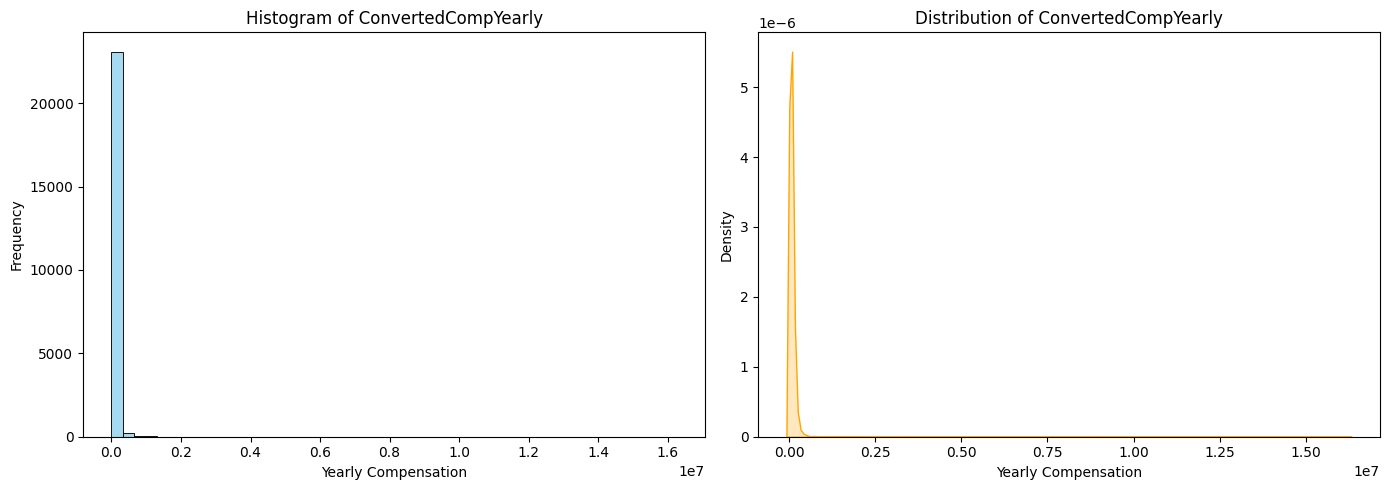

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(url)

comp = df['ConvertedCompYearly'].dropna()

print("Summary Statistics:")
print(comp.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(comp, bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram of ConvertedCompYearly')
axes[0].set_xlabel('Yearly Compensation')
axes[0].set_ylabel('Frequency')


sns.kdeplot(comp, fill=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of ConvertedCompYearly')
axes[1].set_xlabel('Yearly Compensation')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [5]:
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(url)

full_time = df[df['Employment'] == 'Employed, full-time']

median_comp = full_time['ConvertedCompYearly'].median()

print("Median Yearly Compensation (Employed, full-time):")
print(f"${median_comp:,.2f}")


print("\nNumber of full-time respondents:")
print(full_time['ConvertedCompYearly'].count())

Median Yearly Compensation (Employed, full-time):
$69,814.00

Number of full-time respondents:
17586


<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



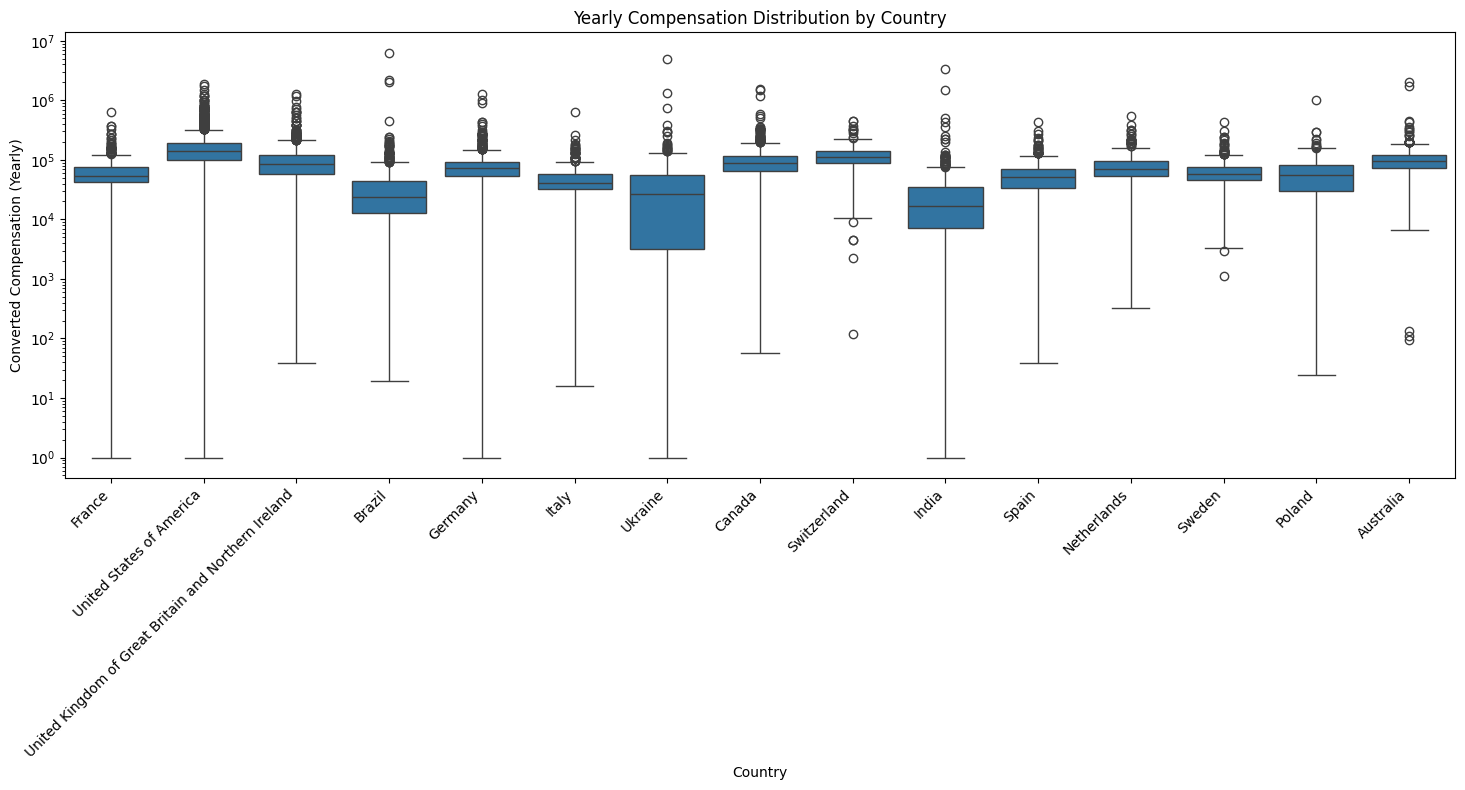

                                                    count    median  \
Country                                                               
United States of America                             4677  143000.0   
Switzerland                                           386  111417.0   
Australia                                             510   95465.5   
Canada                                                871   87231.0   
United Kingdom of Great Britain and Northern Ir...   1391   84076.0   
Germany                                              2046   73036.0   
Netherlands                                           561   69814.0   
Sweden                                                457   57230.0   
Poland                                                586   55535.5   
France                                                918   53703.0   
Spain                                                 559   51555.0   
Italy                                                 540   41619.5   
Ukrain

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(url)

country_comp = df[['Country', 'ConvertedCompYearly']].dropna()

top_countries = (
    country_comp['Country']
    .value_counts()
    .head(15)
    .index
)

filtered_df = country_comp[
    country_comp['Country'].isin(top_countries)
]

plt.figure(figsize=(15, 8))

sns.boxplot(
    data=filtered_df,
    x='Country',
    y='ConvertedCompYearly'
)

plt.title('Yearly Compensation Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Converted Compensation (Yearly)')
plt.xticks(rotation=45, ha='right')


plt.yscale('log')

plt.tight_layout()
plt.show()

country_stats = (
    filtered_df.groupby('Country')['ConvertedCompYearly']
    .agg(['count', 'median', 'mean', 'min', 'max'])
    .sort_values('median', ascending=False)
)

print(country_stats)

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [7]:
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(url)

comp = df['ConvertedCompYearly'].dropna()

Q1 = comp.quantile(0.25)
Q3 = comp.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_refined = df[
    (df['ConvertedCompYearly'].isna()) |
    (
        (df['ConvertedCompYearly'] >= lower_bound) &
        (df['ConvertedCompYearly'] <= upper_bound)
    )
].copy()

print("Original dataset shape:", df.shape)
print("Refined dataset shape:", df_refined.shape)
print("Rows removed:", df.shape[0] - df_refined.shape[0])


print("\nOutlier bounds:")
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Original dataset shape: (65437, 114)
Refined dataset shape: (64459, 114)
Rows removed: 978

Outlier bounds:
Lower bound: -80177.25
Upper bound: 220860.75


<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


Correlation Matrix:
                     ConvertedCompYearly   WorkExp  JobSatPoints_1
ConvertedCompYearly             1.000000  0.153182        0.020156
WorkExp                         0.153182  1.000000       -0.028839
JobSatPoints_1                  0.020156 -0.028839        1.000000


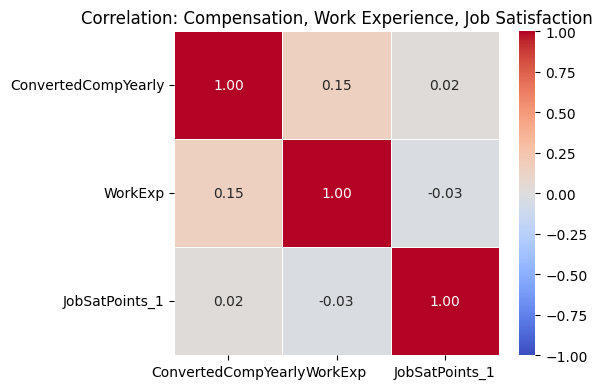

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(url)


cols = ['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']
data = df[cols].dropna()

corr_matrix = data.corr()

print("Correlation Matrix:")
print(corr_matrix)


plt.figure(figsize=(6, 4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    fmt=".2f"
)

plt.title('Correlation: Compensation, Work Experience, Job Satisfaction')
plt.tight_layout()
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


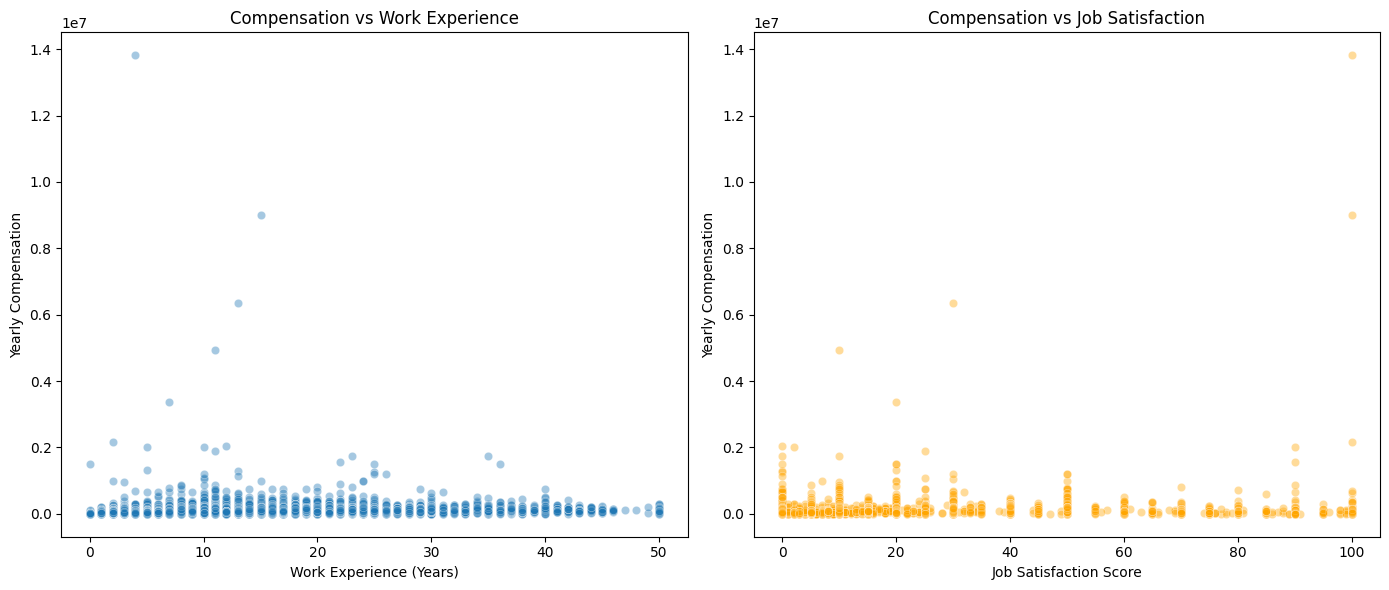

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(url)

cols = ['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']
data = df[cols].dropna()

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(
    data=data,
    x='WorkExp',
    y='ConvertedCompYearly',
    alpha=0.4
)
plt.title('Compensation vs Work Experience')
plt.xlabel('Work Experience (Years)')
plt.ylabel('Yearly Compensation')


plt.subplot(1, 2, 2)
sns.scatterplot(
    data=data,
    x='JobSatPoints_1',
    y='ConvertedCompYearly',
    alpha=0.4,
    color='orange'
)
plt.title('Compensation vs Job Satisfaction')
plt.xlabel('Job Satisfaction Score')
plt.ylabel('Yearly Compensation')

plt.tight_layout()
plt.show()

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
